In [1]:
# Simple Linear Regression

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Read the dataset
df=pd.read_csv("../dataset/height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


<Axes: xlabel='Weight', ylabel='Height'>

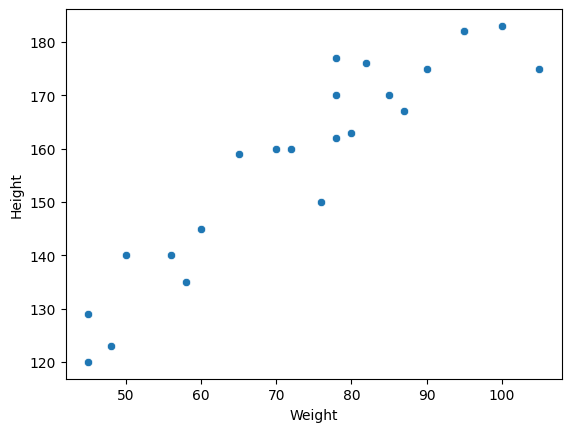

In [4]:
sns.scatterplot(df,x="Weight",y="Height")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


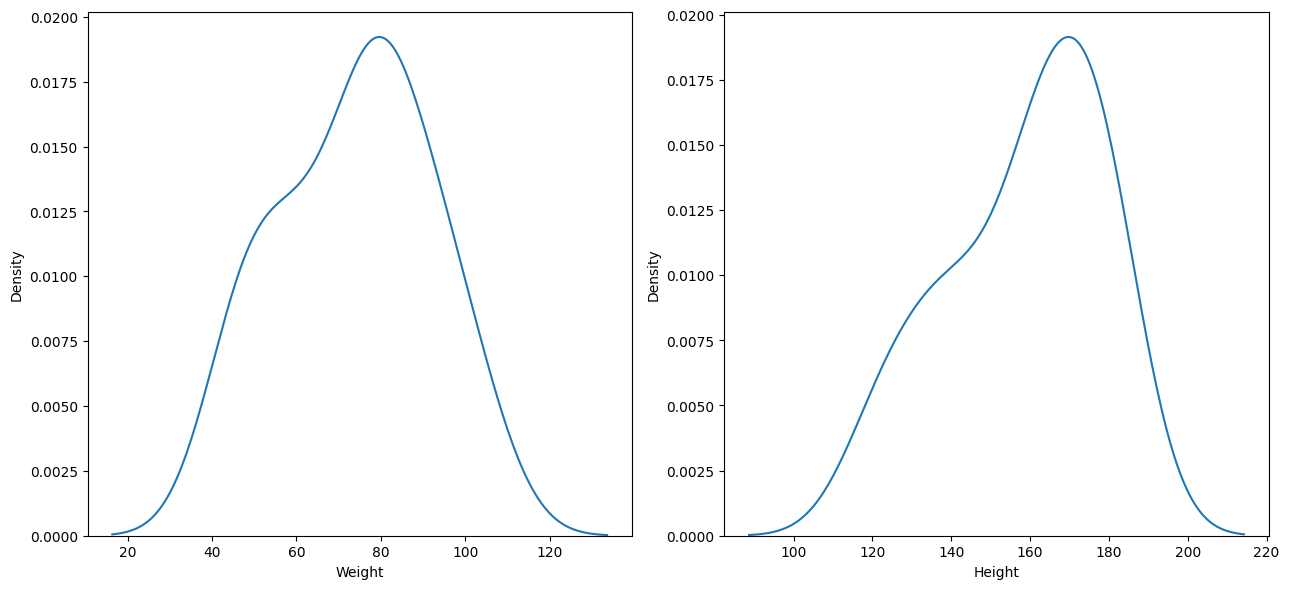

In [6]:
# Distribution of Features
plt.figure(figsize=(13,6))
plt.subplot(1,2,1)
sns.kdeplot(df["Weight"])
plt.subplot(1,2,2)
sns.kdeplot(df["Height"])
plt.tight_layout()

<Axes: xlabel='Weight', ylabel='Height'>

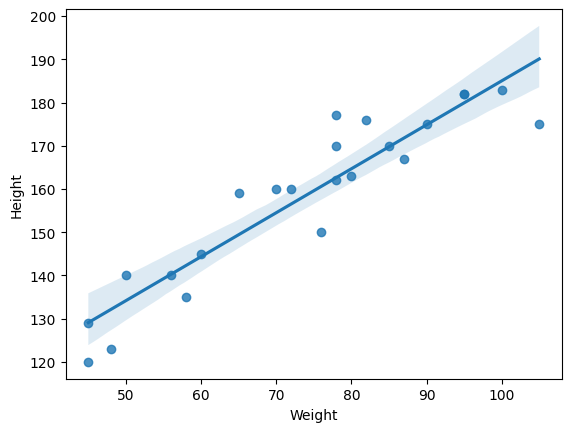

In [7]:
sns.regplot(df,x="Weight",y="Height")

## Whenever we want to train our ML Algorithm

- Divide the dataset features based on independent and dependent features
- Train Test Split of Dataset
- Standardize the data --- weight is calculated in different unit height is being calculated in different unit, the scaling of both weight and height are different
    we are scaling so our gradient descent will happen quickly, if x will be scaled to close to -3 to 3, the coeff value will decrease largely, error will have smaller number -- quick converge through gradient descent (distance and optimization based we use standardization)
- Train our model - Simple Linear Regression Model (Since we have only one feature)

In [8]:
# Divide independent and dependent features
X=df[["Weight"]] # Independent
y=df["Height"] # Dependent

In [9]:
X.shape,y.shape

((23, 1), (23,))

In [10]:
# Dividing into Training and Test datasets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [11]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((18, 1), (5, 1), (18,), (5,))

In [12]:
# Standardize the Training Data (We will use Zscore here)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [13]:
X_train=scaler.fit_transform(X_train) # fit will compute the standard dev and mean of the X_train and then compute Zscore
X_test=scaler.transform(X_test) # We will not need to calculate the standard dev and mean again for X_test and directly compute the Zscore using X_train values (we do this to prevent data leakage)
# Model should not know anything about the test data

In [14]:
X_train.shape,X_test.shape

((18, 1), (5, 1))

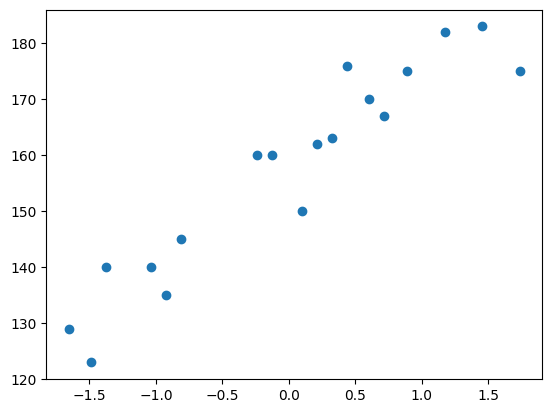

In [15]:
plt.scatter(X_train,y_train)

In [16]:
## Train the Model
## Simple Linear Regression Model -- We have only 1 feature
from sklearn.linear_model import LinearRegression
regression=LinearRegression(n_jobs=-1)

In [17]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
print(f"{regression.coef_ = } and {regression.intercept_ = }")

regression.coef_ = array([17.03440872]) and regression.intercept_ = np.float64(157.5)


In [19]:
# # ## Prediction of Train data
# # 1. predicted_height_output=intercept+Coeff* weight(i.e train weight points)
# y_pred_train=157.5+17.03*(X_train)
# # ## Prediction of Test data
# # predicted_height output=intercept + coeff*weight(i.e test weight points)
# y_pred_train=157.5+17.03*(X_test)

In [20]:
y_pred=regression.predict(X_test)

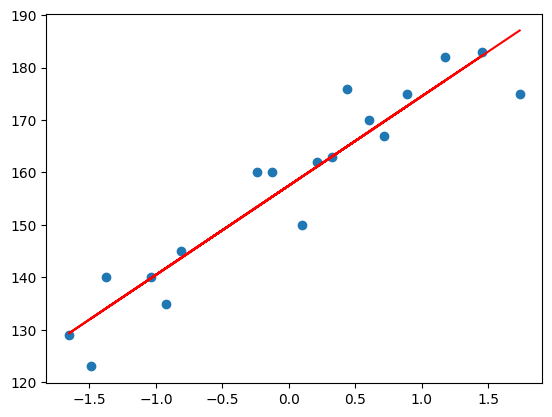

In [21]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),color="r")

Text(0.5, 1.0, 'Regression Plot for Test Dataset')

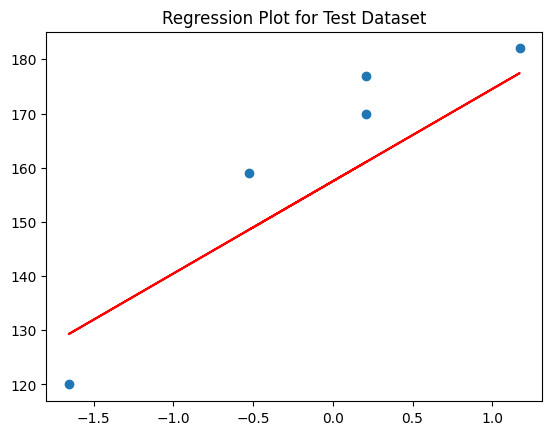

In [22]:
plt.scatter(X_test,y_test)
plt.plot(X_test,y_pred,"r")
plt.title("Regression Plot for Test Dataset")

In [23]:
## We can compare the y_test and y_pred to get the accuracy
## Performance Metrics

In [24]:
# mse,mae,rmse,r2_score, adjusted r2
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error,r2_score

print(f"{mean_squared_error(y_test,y_pred) = }")
print(f"{mean_absolute_error(y_test,y_pred) = }")
print(f"{root_mean_squared_error(y_test,y_pred) = }")

# R2 = 1 - SSR/SST
r2=r2_score(y_test,y_pred)
print(f"{r2 = }")

adjusted_r2=1 - (1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print(f"{adjusted_r2 = }")

mean_squared_error(y_test,y_pred) = 109.77592599051664
mean_absolute_error(y_test,y_pred) = 9.822657814519232
root_mean_squared_error(y_test,y_pred) = 10.477400726827081
r2 = 0.776986986042344
adjusted_r2 = 0.7026493147231252


In [25]:
## Assumption -- To get to know if the model is good or not

In [26]:
regression

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
# Whenever we get a new datapoint
new_weight=80
scaled_new_weight=scaler.transform([[new_weight]])
scaled_new_weight

array([[0.32350772]])

In [28]:
print("Height Prediction for Weight 80kg is",regression.predict(scaled_new_weight))

Height Prediction for Weight 80kg is [163.01076266]


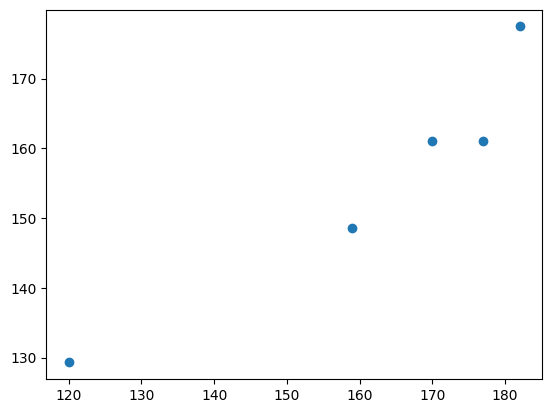

In [29]:
## Assumptions -- If model is good or not
## Plot scatter plot for prediction
plt.scatter(y_test,y_pred)
#sns.regplot(x=y_test,y=y_pred)

In [30]:
## Residuals
residuals=y_test-y_pred
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Density'>

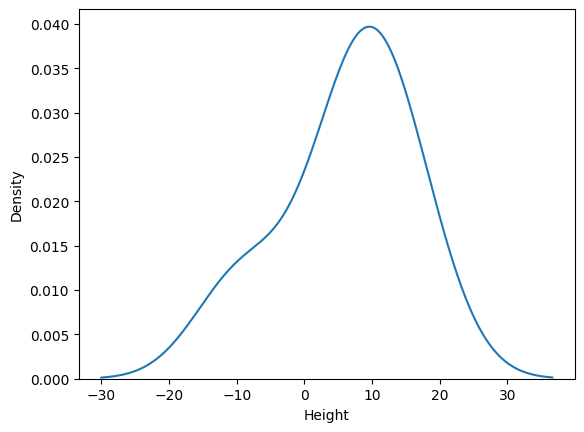

In [31]:
# If we plot the residuals -- should be normal distribution
sns.kdeplot(residuals)

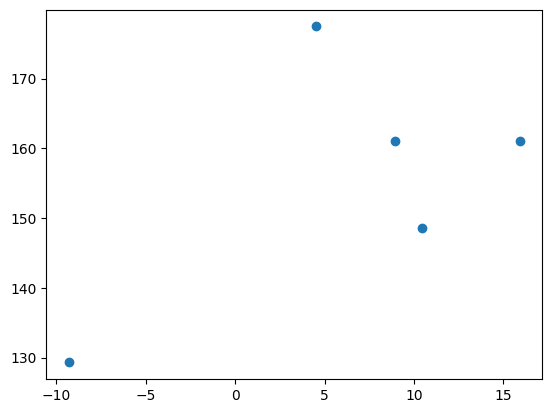

In [32]:
# If we create scatter plot wrt to residuals and predictions -- should be uniform -- for model to be good
plt.scatter(residuals,y_pred)

In [33]:
## Pickling the model